In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cleaned.csv")

In [3]:
df.shape

(120000, 34)

### Target column and input columns

In [4]:
y = df['fit_label']

In [5]:
X = df[[
    'education',
    'years_experience',
    'candidate_location',
    'candidate_preferred_work_mode',
    'student_year_of_study',
    'student_cgpa',
    'student_num_projects',
    'student_certifications',
    'student_internships',
    'student_github_repos',
    'student_hackathons_participated',
    'student_coding_platform_rating',
    'student_weekly_study_hours',
    'student_career_label',
    'student_experience_level',
    'student_interests',
    'job_title',
    'required_experience',
    'job_location',
    'work_mode',
    'company_size',
    'industry',
    'job_duration_months',
    'skill_coverage',
    'experience_gap',
    'project_internship_score',
    'technical_activity_score'
]]

In [6]:
print(X.shape)
print(y.shape)

(120000, 27)
(120000,)


### TRAIN TEST SPLIT

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (96000, 27)
X_test: (24000, 27)
y_train: (96000,)
y_test: (24000,)


In [8]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)


Index(['years_experience', 'student_year_of_study', 'student_cgpa',
       'student_num_projects', 'student_internships', 'student_github_repos',
       'student_hackathons_participated', 'student_coding_platform_rating',
       'student_weekly_study_hours', 'required_experience',
       'job_duration_months', 'skill_coverage', 'experience_gap',
       'project_internship_score', 'technical_activity_score'],
      dtype='object')


In [9]:
cat_cols = X_train.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['education', 'candidate_location', 'candidate_preferred_work_mode',
       'student_certifications', 'student_career_label',
       'student_experience_level', 'student_interests', 'job_title',
       'job_location', 'work_mode', 'company_size', 'industry'],
      dtype='object')


### SCALING & ENCODING

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(96000, 15)
(24000, 15)


In [11]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(96000, 779)
(24000, 779)


In [12]:
X_train_final = pd.concat([
    pd.DataFrame(X_train_scaled, columns=num_cols, index=X_train.index),
    pd.DataFrame(X_train_encoded,columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
], axis=1)

X_test_final = pd.concat([
    pd.DataFrame(X_test_scaled, columns=num_cols, index=X_test.index),
    pd.DataFrame(X_test_encoded,columns=encoder.get_feature_names_out(cat_cols),index=X_test.index)
], axis=1)

In [13]:
print(X_train_final.shape)
print( X_test_final.shape)

(96000, 794)
(24000, 794)


### logistic regression

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_final, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [15]:
y_pred = lr.predict(X_test_final)
print(y_pred[:10])

[0 0 0 1 0 1 0 1 0 1]


In [16]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

alr = accuracy_score(y_test, y_pred)
plr = precision_score(y_test, y_pred)
rl = recall_score(y_test, y_pred)
flr = f1_score(y_test, y_pred)

print("Accuracy :", alr)
print("Precision:", plr)
print("Recall   :", rl)
print("F1 Score :", flr)

Accuracy : 0.8542083333333333
Precision: 0.873347489554079
Recall   : 0.8854166666666666
F1 Score : 0.8793406669195489


The accuracy of logictic regression is 85.42%<br>
precision is 87.34<br>
recall and f1 88.5 & 87.9 The model performs well in identifying suitable candidates 


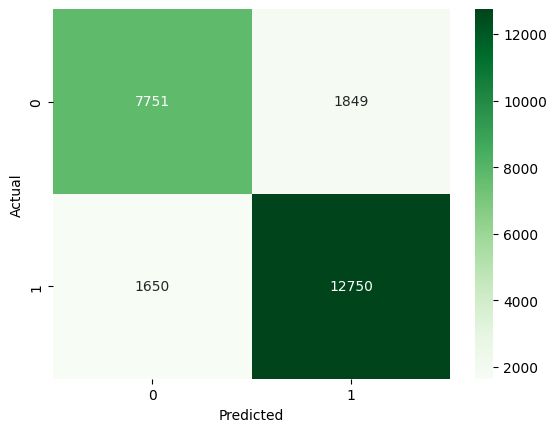

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7751 candidates were correctly predicted as not fit.<br>
12750 candidates were correctly predicted as fit.<br>
1849 fit candidates were wrongly predicted as not fit.<br>
1650 non-fit candidates were wrongly predicted as fit.<br>

### random forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train_final, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [19]:
rf_pred = rf.predict(X_test_final)
print(rf_pred[:10])

[0 0 1 1 0 1 0 1 0 1]


In [20]:
arf = accuracy_score(y_test, rf_pred)
prf = precision_score(y_test, rf_pred)
rrf = recall_score(y_test, rf_pred)
frf = f1_score(y_test, rf_pred)

print("Accuracy :", arf)
print("Precision:", prf)
print("Recall   :", rrf)
print("F1 Score :", frf)

Accuracy : 0.83775
Precision: 0.84441384736428
Recall   : 0.894375
F1 Score : 0.8686766491299069


Accuracy: 83.78% — overall good performance.<br>
Precision: 84.44% — most predicted-fit candidates are actually fit.<br>
Recall: 89.44% — model identifies most fit candidates.<br>
F1 Score: 86.87% — good balance between precision and recall.

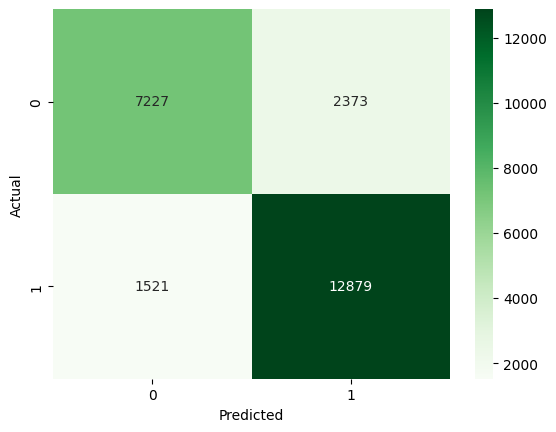

In [21]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7227 candidates correctly classified as not fit.<br>
12879 candidates correctly classified as fit.<br>
2373 not-fit candidates were incorrectly predicted as fit.<br>
1521 fit candidates were incorrectly predicted as not fit.

### xg boost

In [22]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100,random_state=42)
xgb.fit(X_train_final, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [23]:
xgb_pred = xgb.predict(X_test_final)
print(xgb_pred[:10])

[0 0 0 1 0 1 0 1 0 1]


In [24]:
axgb = accuracy_score(y_test, xgb_pred)
pxgb = precision_score(y_test, xgb_pred)
rxgb = recall_score(y_test, xgb_pred)
fxgb = f1_score(y_test, xgb_pred)

print("Accuracy :", axgb)
print("Precision:", pxgb)
print("Recall   :", rxgb)
print("F1 Score :", fxgb)

Accuracy : 0.856
Precision: 0.8745379876796715
Recall   : 0.8872916666666667
F1 Score : 0.8808686659772492


Accuracy: 85.6% — best overall among the three models.<br>
Precision: 87.45% — good prediction of fit candidates.<br>
Recall: 88.73% — identifies most fit candidates.<br>
F1 Score: 88.09% — best balance among other models

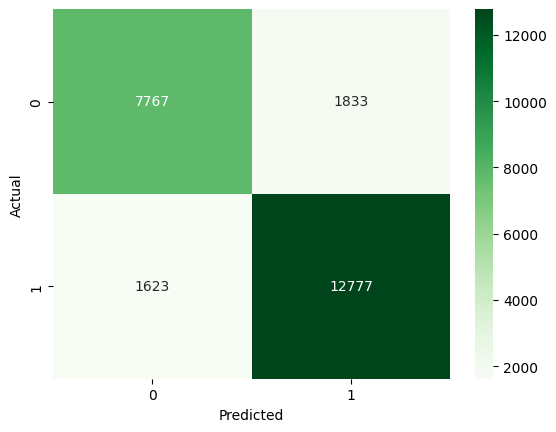

In [25]:
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Fit Score For Person Suitable Or not :-

7767 not-fit candidates correctly predicted as not fit.<br>
12777 fit candidates correctly predicted as fit.<br>
1833 not-fit candidates were predicted as fit.<br>
1623 fit candidates were predicted as not fit.

##FIT_SCORE :-

In [26]:
y_test_fit_score = xgb.predict_proba(X_test_final)[:, 1]
y_train_fit_score = xgb.predict_proba(X_train_final)[:, 1]
fit_comparison = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Suitability_Fit_Score': y_test_fit_score
}, index=X_test.index)

print(fit_comparison.head(10))

        Actual_Label  Predicted_Label  Suitability_Fit_Score
95202              0                0               0.080152
54351              0                0               0.027757
67139              1                0               0.339248
77772              0                1               0.599256
118923             1                0               0.146246
51968              1                1               0.966297
49005              0                0               0.254303
51819              0                1               0.980420
15597              0                0               0.017138
57868              1                1               0.819843


In [27]:
test_results_df = df.loc[X_test.index].copy()
test_results_df['suitability_fit_score'] = y_test_fit_score
test_results_df['suitability_pred_label'] = y_pred
test_results_df.to_csv('test_suitability_fit_scores.csv', index=True)
print("Saved 'test_suitability_fit_scores.csv' successfully")

Saved 'test_suitability_fit_scores.csv' successfully


### comparision

In [30]:
comparison = pd.DataFrame({"Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [ alr,arf,axgb],
    "Precision": [plr,prf,pxgb],
    "Recall": [rl,rrf,rxgb],
    "F1 Score": [flr,frf,fxgb]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.854208   0.873347  0.885417  0.879341
1        Random Forest  0.837750   0.844414  0.894375  0.868677
2              XGBoost  0.856000   0.874538  0.887292  0.880869


XGBoost is the best model with the highest accuracy 85.60% and F1 score 88.09%.<br>
It also has good precision 87.45% and recall 88.73%

### REGRESSION PART

In [31]:
print(df.columns)

Index(['candidate_id', 'job_id', 'candidate_skills', 'education',
       'years_experience', 'candidate_location',
       'candidate_preferred_work_mode', 'job_title', 'required_skills',
       'required_experience', 'job_location', 'work_mode', 'company_size',
       'industry', 'job_duration_months', 'skill_overlap', 'skill_coverage',
       'student_year_of_study', 'student_cgpa', 'student_num_projects',
       'student_certifications', 'student_internships', 'student_github_repos',
       'student_hackathons_participated', 'student_coding_platform_rating',
       'student_weekly_study_hours', 'student_career_label',
       'student_experience_level', 'student_interests', 'fit_label',
       'expected_salary_lpa', 'experience_gap', 'project_internship_score',
       'technical_activity_score'],
      dtype='object')


In [32]:
salary_df = df[df["fit_label"] == 1].copy()

print("Fit candidates:", salary_df.shape[0])
print(salary_df["expected_salary_lpa"].describe())

Fit candidates: 72000
count    72000.000000
mean        10.200886
std          1.509773
min          4.570000
25%          9.170000
50%         10.190000
75%         11.230000
max         16.570000
Name: expected_salary_lpa, dtype: float64


it will work only if the candidate is  fit 

### Target coln & input coln

In [33]:
y_salary=salary_df["expected_salary_lpa"]

In [34]:
X_salary = salary_df.drop(columns=[ "expected_salary_lpa", "fit_label", "candidate_id", "job_id",  "candidate_skills", 
"required_skills", "student_certifications","student_interests","student_hackathons_participated",'student_coding_platform_rating'
,'student_weekly_study_hours'])
print(X_salary.shape)

(72000, 23)


### train test split

In [35]:
from sklearn.model_selection import train_test_split
X_train_salary, X_test_salary, y_train_salary, y_test_salary = train_test_split( X_salary, y_salary, test_size=0.2, random_state=42)
print( X_train_salary.shape)
print( X_test_salary.shape)

(57600, 23)
(14400, 23)


In [36]:
y_train_salary_log=np.log1p(y_train_salary)
y_test_salary_log=np.log1p(y_test_salary)
print(y_train_salary_log.head())
print(y_test_salary_log.head())

103412    2.498152
71322     2.603430
50596     2.443216
37486     2.393339
33314     2.507972
Name: expected_salary_lpa, dtype: float64
81795     2.193886
25334     2.536075
62087     2.424803
81106     2.481568
102487    2.482404
Name: expected_salary_lpa, dtype: float64


### Scaling and encoding

In [37]:
num_cols_salary = X_train_salary.select_dtypes(include=["int64", "float64"]).columns
print(num_cols_salary)

Index(['years_experience', 'required_experience', 'job_duration_months',
       'skill_overlap', 'skill_coverage', 'student_year_of_study',
       'student_cgpa', 'student_num_projects', 'student_internships',
       'student_github_repos', 'experience_gap', 'project_internship_score',
       'technical_activity_score'],
      dtype='object')


In [38]:
cat_cols_salary = X_train_salary.select_dtypes(include=["object"]).columns
print(cat_cols_salary)

Index(['education', 'candidate_location', 'candidate_preferred_work_mode',
       'job_title', 'job_location', 'work_mode', 'company_size', 'industry',
       'student_career_label', 'student_experience_level'],
      dtype='object')


In [39]:
from sklearn.preprocessing import RobustScaler
scaler_salary = RobustScaler()

X_train_salary_scaled = scaler_salary.fit_transform( X_train_salary[num_cols_salary])
X_test_salary_scaled = scaler_salary.transform(X_test_salary[num_cols_salary])

print( X_train_salary_scaled.shape)
print( X_test_salary_scaled.shape)

(57600, 13)
(14400, 13)


In [40]:
from sklearn.preprocessing import OneHotEncoder

encoder_salary = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

X_train_salary_encoded = encoder_salary.fit_transform( X_train_salary[cat_cols_salary])

X_test_salary_encoded = encoder_salary.transform(X_test_salary[cat_cols_salary])

print( X_train_salary_encoded.shape)
print( X_test_salary_encoded.shape)

(57600, 67)
(14400, 67)


In [41]:
X_train_salary_final = pd.concat([
    pd.DataFrame(X_train_salary_scaled,columns=num_cols_salary,index=X_train_salary.index),
    
    pd.DataFrame( X_train_salary_encoded, columns=encoder_salary.get_feature_names_out(cat_cols_salary), index=X_train_salary.index)
], axis=1)


X_test_salary_final = pd.concat([
    pd.DataFrame(X_test_salary_scaled,columns=num_cols_salary,index=X_test_salary.index),
    
    pd.DataFrame( X_test_salary_encoded, columns=encoder_salary.get_feature_names_out(cat_cols_salary), index=X_test_salary.index)
], axis=1)


print( X_train_salary_final.shape)
print( X_test_salary_final.shape)

(57600, 80)
(14400, 80)


### Linear regression

In [42]:
from sklearn.linear_model import LinearRegression

salary_lr = LinearRegression()
salary_lr.fit(X_train_salary_final,y_train_salary_log)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](80,)","[ 0.08, 0.07, 0.03,..., 0. ,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](80,)","['years_experience','required_experience','job_duration_months',..., 'student_experience_level_Advanced','student_experience_level_Beginner', 'student_experience_level_Intermediate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.374
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,80
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,68


In [43]:
pred_log=salary_lr.predict(X_test_salary_final)
print("Predicted Log Salaries : \n",pred_log[:10])

Predicted Log Salaries : 
 [2.295955   2.421834   2.41612465 2.34312844 2.46441332 2.43574074
 2.63628862 2.27417608 2.37988676 2.48209196]


In [44]:
salary_pred=np.expm1(pred_log)
print(salary_pred[:10])

[ 8.93391839 10.26650313 10.20236199  9.41376453 10.75658278 10.42427805
 12.96129173  8.71990732  9.80367939 10.96627126]


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test_salary, salary_pred)
rmse = np.sqrt(mean_squared_error(y_test_salary, salary_pred))
r2 = r2_score(y_test_salary, salary_pred)
print("TESTING ACCURACY")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2:", r2)

TESTING ACCURACY
MAE : 0.6910425847568971
RMSE: 0.8631954162498425
R2: 0.6705549937483953


The regression model achieved R2 score of 67.46% that explains a significant portion of salary variation.<br>
MAE & RMSE shows larger prediction errors<br>

##Training Accuracy :-

In [46]:
train_pred_log=salary_lr.predict(X_train_salary_final)
train_pred=np.expm1(train_pred_log)
print("R2 Score For Taraining Data :- \n")
print("R2_Score :",r2_score(y_train_salary,train_pred))
print("Mean_Absolute_Error : ",mean_absolute_error(y_train_salary,train_pred))
print("Mean_Squared_error : ",np.sqrt(mean_squared_error(y_train_salary, train_pred)))


R2 Score For Taraining Data :- 

R2_Score : 0.6769159970893488
Mean_Absolute_Error :  0.6844824776525666
Mean_Squared_error :  0.8589875791787573


### XGboost

In [47]:
from xgboost import XGBRegressor

xgb_salary = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,reg_alpha=0.1,reg_lambda=1,colsample_bytree=0.8 ,random_state=42)
xgb_salary.fit( X_train_salary_final, y_train_salary_log)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
pred_log_xgb = xgb_salary.predict(X_test_salary_final)
print("Predicted log salaries:")
print(pred_log_xgb[:10])

Predicted log salaries:
[2.342655  2.4363663 2.4137318 2.338365  2.474099  2.443711  2.6143935
 2.269921  2.3793201 2.4786258]


In [49]:
xgb_salary_pred=np.expm1(pred_log_xgb)
xgb_salary_pred

array([ 9.408834, 10.431427, 10.175589, ..., 10.11033 ,  9.290573,
       11.530977], shape=(14400,), dtype=float32)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
xgb_mae = mean_absolute_error(y_test_salary, xgb_salary_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_salary, xgb_salary_pred))
xgb_r2 = r2_score(y_test_salary, xgb_salary_pred)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²  :", xgb_r2)

XGBoost MAE : 0.6980080891688665
XGBoost RMSE: 0.8738117111892995
XGBoost R²  : 0.6624015842703289


XGboost achieved R2 score of 66.50% that explains a significant portion of salary variation.<br>
MAE & RMSE shows larger prediction errors<br>

In [51]:
from sklearn.ensemble import HistGradientBoostingRegressor
model=HistGradientBoostingRegressor(learning_rate=0.1,max_depth=None,l2_regularization=0,max_iter=100,max_leaf_nodes=31,random_state=42)
model.fit(X_train_salary_final,y_train_salary_log)



,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [52]:
pred_log_hist=model.predict(X_test_salary_final)
print(pred_log_hist[:10])

[2.32408892 2.4274265  2.41713105 2.32869813 2.49964152 2.45904734
 2.60395468 2.28228539 2.35661148 2.48147906]


In [53]:
pred_hist=np.expm1(pred_log_hist)
print(pred_hist[:10])

[ 9.21736696 10.32968762 10.21364178  9.26456965 11.17812761 10.69366616
 12.51708821  8.7990495   9.55512454 10.95893935]


##Testing Accuracy :-

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
e_mae = mean_absolute_error(y_test_salary,pred_hist)
e_rmse = np.sqrt(mean_squared_error(y_test_salary, pred_hist))
e_r2 = r2_score(y_test_salary, pred_hist)

print("HistGradientBoostingRegressor MAE :", e_mae)
print("HistGradientBoostingRegressor RMSE:", e_rmse)
print("HistGradientBoostingRegressor R²  :", e_r2)

HistGradientBoostingRegressor MAE : 0.6992366074390202
HistGradientBoostingRegressor RMSE: 0.875693946821422
HistGradientBoostingRegressor R²  : 0.660945608928375


##Training Accuracy :-

In [55]:
train_pred_hist_log=model.predict(X_train_salary_final)
train_pred_hist=np.expm1(train_pred_log)

train_pred_hist

array([10.55771732, 11.37063861, 10.66231774, ..., 12.45947396,
       13.85172946,  9.03097255], shape=(57600,))

In [56]:
mae = mean_absolute_error(y_train_salary,train_pred_hist)
rmse = np.sqrt(mean_squared_error(y_train_salary, train_pred_hist))
r2 = r2_score(y_train_salary, train_pred_hist)

print("Hist MAE :", mae)
print("Hist RMSE:", rmse)
print("Hist R²  :", r2)

Hist MAE : 0.6844824776525666
Hist RMSE: 0.8589875791787573
Hist R²  : 0.6769159970893488


In [57]:
comparison = pd.DataFrame({"Model": ["Linear Regression","XGBoost","HistGradientBoostingRegressor"],
    "MAE": [mae,xgb_mae,e_mae],
    "RMSE": [rmse,xgb_rmse,e_rmse],
    "R2": [r2,xgb_r2,e_r2]
})

print(comparison)

                           Model       MAE      RMSE        R2
0              Linear Regression  0.684482  0.858988  0.676916
1                        XGBoost  0.698008  0.873812  0.662402
2  HistGradientBoostingRegressor  0.699237  0.875694  0.660946


In [61]:
import joblib

joblib.dump(xgb, "xgboost_fit_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump({'num': list(num_cols_salary),
             'cat': list(cat_cols_salary),
             'final_cols': list(X_train_salary_final.columns)}, "salary_columns.pkl")

['salary_columns.pkl']

##FIT_SCORE :-

In [58]:
from sklearn.preprocessing import MinMaxScaler
train_pred_log = salary_lr.predict(X_train_salary_final)
salary_pred_train = np.expm1(train_pred_log)
salary_score_scaler = MinMaxScaler()
fit_score_salary_train = salary_score_scaler.fit_transform(salary_pred_train.reshape(-1, 1)).flatten()
fit_score_salary_test = salary_score_scaler.transform(salary_pred.reshape(-1, 1)).flatten()
salary_fit_comparison = pd.DataFrame({
    'Actual_Salary_LPA': y_test_salary,
    'Predicted_Salary_LPA': salary_pred,
    'Salary_Fit_Score': fit_score_salary_test
}, index=X_test_salary.index)
test_salary_results_df = salary_df.loc[X_test_salary.index].copy()
test_salary_results_df['predicted_log_salary'] = pred_log
test_salary_results_df['predicted_salary_lpa'] = salary_pred
test_salary_results_df['salary_fit_score'] = fit_score_salary_test
test_salary_results_df.to_csv('test_salary_fit_scores.csv', index=True)
print("Saved 'test_salary_fit_scores.csv' successfully!")


Saved 'test_salary_fit_scores.csv' successfully!


from overall comparision the linear regression is best  in both models

In [59]:
import joblib 
joblib.dump(xgb_salary,"XG_Boostgit_Regressor.pkl")

['XG_Boostgit_Regressor.pkl']

In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
unsupervised_assets = joblib.load('recommender.pkl')
tfidf = unsupervised_assets['tfidf']
jobs = unsupervised_assets['jobs']
joblib.dump({
    'tfidf': tfidf,
    'jobs': jobs,
    'xgb_model': xgb,                  
    'salary_lr': salary_lr,             
    'salary_scaler': salary_score_scaler 
}, 'final_matcher.pkl')

print("Successfully merged Unsupervised + supervised into 'final_matcher.pkl'!")

Successfully merged Unsupervised + Supervised into 'final_matcher.pkl'!
